# Command Following — Motor ERD Analysis

Measures volitional motor imagery via **Event-Related Desynchronization (ERD)**.  
A patient following the command "keep opening and closing your hand" should show
**power decreases in mu (8–12 Hz) and beta (14–30 Hz)** at contralateral motor electrodes
compared to the rest (stop) condition.

| Condition | Instruction | Expected response |
| --- | --- | --- |
| Keep | "Keep moving" | ERD at contralateral C3/C4 |
| Stop | "Stop moving" | Baseline / ERS (event-related synchronization) |

**Schema note:**
- CON010/013: `right_command` / `left_command` — run-level rows, 8 keep+stop cycles reconstructed
- CON011/012: `right_command+p` / `left_command+p` — same, with prompt

A **positive finding** is significant ERD (p < 0.05) in mu and/or beta at the contralateral motor
channel, with lateralization matching the commanded hand.

**Environment:** `stimulus_software/.venv` (MNE 1.11, scipy, pandas, matplotlib)

## 1. Configuration

**How to run this notebook:**

1. Run **cell 1a** — a session dropdown appears. Pick the patient and date.
2. Run **cell 1b** — reads your selection and sets up all file paths. Check the printed output looks correct.
3. Click on cell 1b, then choose **Run → Run Selected Cell and All Below** from the menu to execute the rest of the notebook in one go.

> To switch patients mid-session: change the dropdown, re-run cell 1b, then use **Run → Run Selected Cell and All Below** again.

In [14]:
import sys
import re
from pathlib import Path
import ipywidgets as widgets
from IPython.display import display

ANALYSIS_ROOT = Path.cwd().resolve()
if ANALYSIS_ROOT.name != 'analysis':
    ANALYSIS_ROOT = next(
        (parent for parent in [ANALYSIS_ROOT, *ANALYSIS_ROOT.parents]
         if parent.name == 'analysis' and (parent / 'notebooks').exists()),
        ANALYSIS_ROOT,
    )
if str(ANALYSIS_ROOT) not in sys.path:
    sys.path.insert(0, str(ANALYSIS_ROOT))

from lib.io import DEFAULT_EEG_CHANNELS

repo_root = ANALYSIS_ROOT.parent
csv_dir = repo_root / 'stimulus_software' / 'patient_data' / 'results'
edf_dir = repo_root / 'stimulus_software' / 'patient_data' / 'edfs'

edf_by_patient = {
    f.name.replace('_clipped.EDF', '').replace('_clipped.edf', ''): f
    for f in sorted(edf_dir.glob('*.[Ee][Dd][Ff]'))
    if '_clipped' in f.name
}

def _parse_csv(path):
    m = re.search(r'(\d{4}-\d{2}-\d{2})_stimulus_results', path.stem)
    if not m:
        return None
    date = m.group(1)
    patient_id = path.stem[:path.stem.index('_' + date)]
    return patient_id, date

sessions = []
for f in sorted(csv_dir.glob('*_stimulus_results.csv')):
    parsed = _parse_csv(f)
    if parsed is None:
        continue
    pid, date = parsed
    sessions.append({'csv': f, 'patient_id': pid, 'date': date, 'edf': edf_by_patient.get(pid)})

options = [(f'{s["patient_id"]}  —  {s["date"]}', i) for i, s in enumerate(sessions)]

csv_dropdown = widgets.Dropdown(
    options=options,
    description='Session:',
    layout=widgets.Layout(width='360px'),
    style={'description_width': 'initial'},
)
edf_status = widgets.Label()

def _on_change(_):
    s = sessions[csv_dropdown.value]
    edf_status.value = f'EDF: {s["edf"].name}' if s['edf'] else '⚠  No matching EDF found for this patient'

csv_dropdown.observe(_on_change, names='value')
_on_change(None)

display(csv_dropdown, edf_status)
print('Select a session above, then run the next cell.')

Dropdown(description='Session:', layout=Layout(width='360px'), options=(('CON010  —  2026-03-06', 0), ('CON011…

Label(value='EDF: CON010_clipped.EDF')

Select a session above, then run the next cell.


### 1b. Confirm selection — run after choosing from the dropdown above

In [15]:
_sel = sessions[csv_dropdown.value]
SUBJECT_ID   = _sel['patient_id']
SESSION_DATE = _sel['date']
CSV_PATH     = _sel['csv']
EDF_PATH     = _sel['edf']

if EDF_PATH is None or not EDF_PATH.exists():
    raise FileNotFoundError(
        f'No EDF found for {SUBJECT_ID} — '
        f'add {SUBJECT_ID}_clipped.EDF to patient_data/edfs/'
    )

OUT_DIR = ANALYSIS_ROOT / 'results' / SUBJECT_ID / 'command'
OUT_DIR.mkdir(parents=True, exist_ok=True)

EEG_CHANNELS = DEFAULT_EEG_CHANNELS.copy()
BAD_CHANNELS = []

print(f'Subject:    {SUBJECT_ID}')
print(f'Date:       {SESSION_DATE}')
print(f'EDF:        {EDF_PATH.name}')
print(f'CSV:        {CSV_PATH.name}')
print(f'Output dir: {OUT_DIR}')

Subject:    CON013
Date:       2026-04-10
EDF:        CON013_clipped.EDF
CSV:        CON013_2026-04-10_stimulus_results.csv
Output dir: /Users/joey/Documents/EEG Project/code/analysis/results/CON013/command


## 2. Imports

In [16]:
import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt
from scipy import stats

from lib.io import align_stimulus_csv, load_raw_eeg_metadata
from lib.preprocessing import load_filtered_eeg

%matplotlib inline
mne.set_log_level('WARNING')
print(f'MNE {mne.__version__}')

MNE 1.11.0


## 3. Load EDF + Sync Alignment

In [17]:
raw, sfreq, available_eeg = load_raw_eeg_metadata(
    EDF_PATH,
    eeg_channels=EEG_CHANNELS,
    bad_channels=BAD_CHANNELS,
    preload=False,
    verbose=False,
)

print(f'EEG channels ({len(available_eeg)}): {available_eeg}')
print(f'sfreq: {sfreq} Hz  |  duration: {raw.n_times/sfreq:.0f}s')

EEG channels (19): ['Fp1', 'Fp2', 'Fz', 'F3', 'F4', 'F7', 'F8', 'Cz', 'C3', 'C4', 'T3', 'T4', 'T5', 'T6', 'Pz', 'P3', 'P4', 'O1', 'O2']
sfreq: 512.0 Hz  |  duration: 4846s


/Users/joey/Documents/EEG Project/code/analysis/lib/io.py:93: RuntimeWarning: Omitted 5 annotation(s) that were outside data range.
  raw = mne.io.read_raw_edf(edf_path, preload=preload, verbose=verbose)
/Users/joey/Documents/EEG Project/code/analysis/lib/io.py:102: RuntimeWarning: The unit for channel(s) DC10, DC2, DC3, DC4, DC5, DC6, DC7, DC8, DC9 has changed from V to NA.
  raw.set_channel_types({ch: "misc" for ch in dc_channels})


In [18]:
df, time_offset = align_stimulus_csv(CSV_PATH, sfreq=sfreq, n_times=raw.n_times)
print(f'time_offset = {time_offset:.4f} s')

time_offset = -1828.7082 s


## 4. Preprocessing

In [19]:
# 1–40 Hz for motor bands (mu 8–12 Hz, beta 14–30 Hz)
raw_erd = load_filtered_eeg(raw, available_eeg, l_freq=1, h_freq=40, verbose=False)
print('Preprocessing done.')

Preprocessing done.


## 5. Build Keep / Stop Events

Two CSV schemas are supported:

- **Pairs schema** (new, CON011+): one `right_keep` / `right_stop` row per imagery cycle.
  `start_time` / `end_time` directly encode each window — no reconstruction needed.
- **Runs schema** (old, CON010/013): one `right_command` row per 8-cycle run.
  Keep/stop pair timings are estimated from known stimulus constants — see warnings in cell below.

In [20]:
# Detect which command schema is present in the CSV.
has_pairs = df['stim_type'].str.match(r'(right|left)_(keep|stop)', na=False).any()
has_runs  = df['stim_type'].str.contains('command', na=False).any()

SCHEMA = 'pairs' if has_pairs else 'runs' if has_runs else None
if SCHEMA is None:
    raise RuntimeError(
        'No command rows found.\n'
        'Check available types with: df["stim_type"].value_counts()'
    )
print(f'Command schema: {SCHEMA}')

if SCHEMA == 'pairs':
    keep_df = df[df['stim_type'].str.match(r'(right|left)_keep', na=False)].copy()
    stop_df = df[df['stim_type'].str.match(r'(right|left)_stop', na=False)].copy()
    keep_df['side'] = keep_df['stim_type'].str.extract(r'(right|left)')
    stop_df['side'] = stop_df['stim_type'].str.extract(r'(right|left)')
    print(f'Keep rows: {len(keep_df)}  Stop rows: {len(stop_df)}')
    print(keep_df[['stim_type', 'side', 'edf_start', 'edf_end']].to_string())
else:
    cmd_df = df[df['stim_type'].str.contains('command', na=False)].copy()
    cmd_df['side']       = cmd_df['stim_type'].str.extract(r'(right|left)')
    cmd_df['has_prompt'] = cmd_df['stim_type'].str.contains(r'\+p', na=False)
    print(f'Command runs: {len(cmd_df)}')
    print(cmd_df[['stim_type', 'side', 'has_prompt', 'edf_start', 'edf_end']].to_string())

Command schema: runs
Command runs: 6
         stim_type   side  has_prompt    edf_start      edf_end
223   left_command   left       False  2583.828542  2779.686726
224   left_command   left       False  2852.154953  3047.973248
225   left_command   left       False  3227.227863  3423.068308
226  right_command  right       False  3434.608753  3629.900488
227  right_command  right       False  3641.439914  3836.706632
228  right_command  right       False  3848.246074  4043.512798


In [21]:
keep_events, stop_events = [], []
keep_meta,   stop_meta   = [], []

if SCHEMA == 'pairs':
    # New per-pair schema: timings are directly in the CSV, no estimation needed.
    keep_events = np.column_stack([
        keep_df['start_sample'].values,
        np.zeros(len(keep_df), dtype=int),
        np.ones(len(keep_df), dtype=int),
    ])
    stop_events = np.column_stack([
        stop_df['start_sample'].values,
        np.zeros(len(stop_df), dtype=int),
        np.full(len(stop_df), 2, dtype=int),
    ])
    keep_meta_df = keep_df[['side']].reset_index(drop=True)
    stop_meta_df = stop_df[['side']].reset_index(drop=True)

else:
    # Old run-level schema: reconstruct 8 keep+stop pairs per run from timing constants.
    # WARNING: pair onset times are estimated, not measured. Any deviation from these
    # constants (actual prompt audio length, audio playback latency) silently shifts
    # all 8 cycles. Treat ERD results from this schema as approximate.
    # Timing constants — must match stimulus_software lib/constants.py:
    KEEP_PAUSE_S   = 10.0   # keep imagery window (seconds)
    STOP_PAUSE_S   = 10.0   # stop rest window (seconds)
    TOTAL_CYCLES   = 8
    PROMPT_DUR_EST = 4.0    # estimated prompt audio + PROMPT_DELAY

    run_durs   = (cmd_df['edf_end'] - cmd_df['edf_start']).values
    has_prompt = cmd_df['has_prompt'].values

    for i, (_, run) in enumerate(cmd_df.iterrows()):
        effective_dur   = run_durs[i] - (PROMPT_DUR_EST if has_prompt[i] else 0)
        audio_per_cycle = max((effective_dur / TOTAL_CYCLES) - KEEP_PAUSE_S - STOP_PAUSE_S, 1.5)
        keep_audio_est  = audio_per_cycle / 2
        side            = run['side']

        t = run['edf_start'] + (PROMPT_DUR_EST if has_prompt[i] else 0)
        for cycle in range(TOTAL_CYCLES):
            keep_events.append([int(t * sfreq), 0, 1])
            keep_meta.append({'side': side, 'cycle': cycle, 'run': i})

            stop_t = t + keep_audio_est + KEEP_PAUSE_S
            stop_events.append([int(stop_t * sfreq), 0, 2])
            stop_meta.append({'side': side, 'cycle': cycle, 'run': i})

            t = stop_t + keep_audio_est + STOP_PAUSE_S

    keep_events  = np.array(keep_events, dtype=int)
    stop_events  = np.array(stop_events, dtype=int)
    keep_meta_df = pd.DataFrame(keep_meta)
    stop_meta_df = pd.DataFrame(stop_meta)

print(f'Keep events: {len(keep_events)}')
print(f'Stop events: {len(stop_events)}')
print(keep_meta_df.groupby('side').size().rename('cycles').to_string())

Keep events: 48
Stop events: 48
side
left     24
right    24


In [22]:
MOTOR_CHANNELS = [ch for ch in ['C3', 'Cz', 'C4'] if ch in available_eeg]
print(f'Motor channels: {MOTOR_CHANNELS}')

all_cmd_events = np.vstack([keep_events, stop_events])
all_cmd_events = all_cmd_events[all_cmd_events[:, 0].argsort()]

epochs_cmd = mne.Epochs(
    raw_erd, events=all_cmd_events,
    event_id={'keep': 1, 'stop': 2},
    tmin=0, tmax=9.9, baseline=None,
    preload=True, verbose=False
)
print(f'Epochs: {len(epochs_cmd)}  ({len(epochs_cmd["keep"])} keep, {len(epochs_cmd["stop"])} stop)')

Motor channels: ['C3', 'Cz', 'C4']
Epochs: 96  (48 keep, 48 stop)


## 6. Compute ERD

In [23]:
keep_ep = epochs_cmd['keep'].copy().pick(MOTOR_CHANNELS)
stop_ep = epochs_cmd['stop'].copy().pick(MOTOR_CHANNELS)

psd_k = keep_ep.compute_psd(method='welch', fmin=1, fmax=40, verbose=False)
psd_s = stop_ep.compute_psd(method='welch', fmin=1, fmax=40, verbose=False)
data_k, freqs_psd = psd_k.get_data(return_freqs=True)
data_s, _          = psd_s.get_data(return_freqs=True)

# Average across channels for overall ERD spectrum
keep_avg = data_k.mean(axis=(0, 1))
stop_avg = data_s.mean(axis=(0, 1))
erd_db   = 10 * np.log10(keep_avg / (stop_avg + 1e-30))

# Band-average ERD per epoch for statistics
MU_BAND   = (8,  12)
BETA_BAND = (14, 30)

def band_power(data, freqs, fmin, fmax):
    """Mean power across frequency band. data: (n_trials, n_ch, n_freqs)"""
    mask = (freqs >= fmin) & (freqs <= fmax)
    return data[:, :, mask].mean(axis=(1, 2))  # (n_trials,)

mu_k   = band_power(data_k, freqs_psd, *MU_BAND)
mu_s   = band_power(data_s, freqs_psd, *MU_BAND)
beta_k = band_power(data_k, freqs_psd, *BETA_BAND)
beta_s = band_power(data_s, freqs_psd, *BETA_BAND)

print(f'Mu    keep: {mu_k.mean():.2e}   stop: {mu_s.mean():.2e}')
print(f'Beta  keep: {beta_k.mean():.2e}  stop: {beta_s.mean():.2e}')

Mu    keep: 4.92e-12   stop: 5.03e-12
Beta  keep: 1.11e-12  stop: 1.26e-12


## 7. Statistical Test

In [24]:
# Paired t-test: keep < stop would indicate ERD (motor imagery engaging motor cortex)
# One-sided: keep power LESS than stop power => t < 0, p_erd < 0.05
t_mu,   p_mu_two   = stats.ttest_rel(mu_k,   mu_s)
t_beta, p_beta_two = stats.ttest_rel(beta_k, beta_s)

# One-sided p (keep < stop)
p_mu   = p_mu_two   / 2 if t_mu   < 0 else 1 - p_mu_two   / 2
p_beta = p_beta_two / 2 if t_beta < 0 else 1 - p_beta_two / 2

# Cohen's d for effect size
def cohens_d_paired(a, b):
    diff = a - b
    return diff.mean() / (diff.std() + 1e-30)

d_mu   = cohens_d_paired(mu_k,   mu_s)
d_beta = cohens_d_paired(beta_k, beta_s)

print(f'{"Band":<8} {"Keep mean":>12} {"Stop mean":>12} {"t":>8} {"p (1-sided)":>12} {"d":>8} {"Sig":>5}')
print("-" * 65)
for band, pm, t, p, d in [("Mu", "8–12 Hz", t_mu, p_mu, d_mu), ("Beta", "14–30 Hz", t_beta, p_beta, d_beta)]:
    sig = "✓" if p < 0.05 else ""
    print(f'{band:<8} {pm:>12} {"":>12} {t:>8.3f} {p:>12.4f} {d:>8.3f} {sig:>5}')

Band        Keep mean    Stop mean        t  p (1-sided)        d   Sig
-----------------------------------------------------------------
Mu            8–12 Hz                -0.219       0.4139   -0.032      
Beta         14–30 Hz                -0.875       0.1930   -0.128      


## 8. Plots

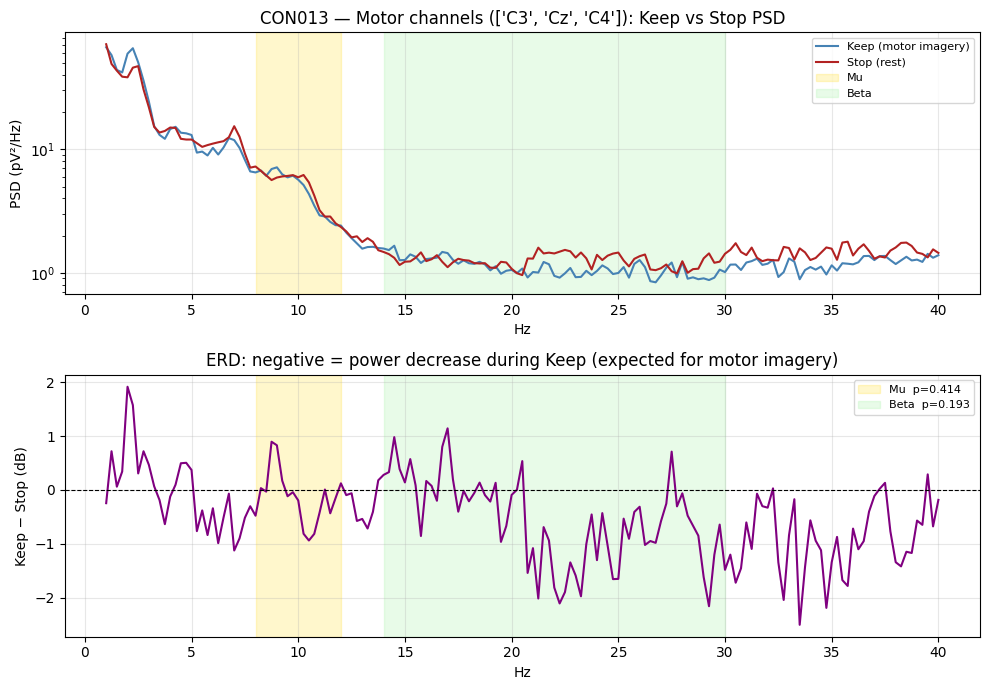

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7))

axes[0].semilogy(freqs_psd, keep_avg * 1e12, color='steelblue', lw=1.5, label='Keep (motor imagery)')
axes[0].semilogy(freqs_psd, stop_avg * 1e12, color='firebrick',  lw=1.5, label='Stop (rest)')
for f0, f1, c, lbl in [(8, 12, 'gold', 'Mu'), (14, 30, 'lightgreen', 'Beta')]:
    axes[0].axvspan(f0, f1, color=c, alpha=0.2, label=lbl)
axes[0].set(xlabel='Hz', ylabel='PSD (pV²/Hz)',
            title=f'{SUBJECT_ID} — Motor channels ({MOTOR_CHANNELS}): Keep vs Stop PSD')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(freqs_psd, erd_db, color='purple', lw=1.5)
axes[1].axhline(0, color='k', lw=0.8, ls='--')
for f0, f1, c, lbl in [(8, 12, 'gold', f'Mu  p={p_mu:.3f}{"✓" if p_mu<0.05 else ""}'),
                        (14, 30, 'lightgreen', f'Beta  p={p_beta:.3f}{"✓" if p_beta<0.05 else ""}')]:
    axes[1].axvspan(f0, f1, color=c, alpha=0.2, label=lbl)
axes[1].set(xlabel='Hz', ylabel='Keep − Stop (dB)',
            title='ERD: negative = power decrease during Keep (expected for motor imagery)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / f'{SUBJECT_ID}_command_erd.png', dpi=150)
plt.show()

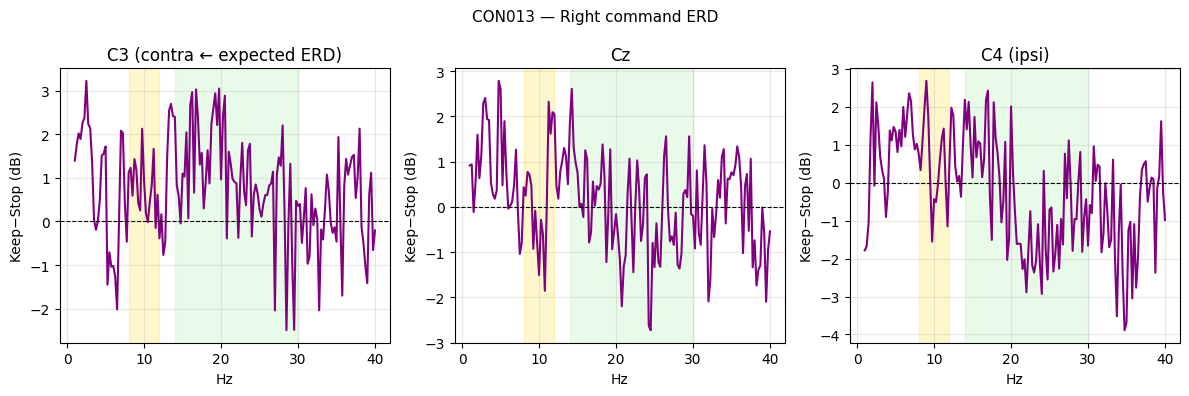

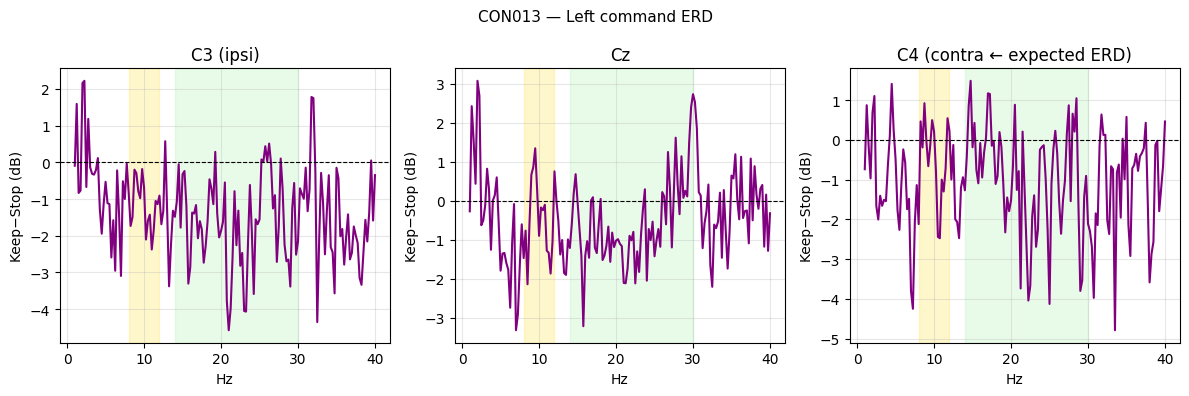

In [26]:
if 'C3' in available_eeg and 'C4' in available_eeg:
    for side in ['right', 'left']:
        contra = 'C3' if side == 'right' else 'C4'
        ipsi   = 'C4' if side == 'right' else 'C3'

        side_keep = keep_meta_df['side'] == side
        side_stop = stop_meta_df['side'] == side
        if side_keep.sum() == 0:
            continue

        ep_k = mne.Epochs(raw_erd, keep_events[side_keep.values], event_id={'keep': 1},
                          tmin=0, tmax=9.9, baseline=None, preload=True, verbose=False)
        ep_s = mne.Epochs(raw_erd, stop_events[side_stop.values], event_id={'stop': 2},
                          tmin=0, tmax=9.9, baseline=None, preload=True, verbose=False)

        fig, axes = plt.subplots(1, len(MOTOR_CHANNELS), figsize=(4 * len(MOTOR_CHANNELS), 4))
        if len(MOTOR_CHANNELS) == 1:
            axes = [axes]

        for ax, ch in zip(axes, MOTOR_CHANNELS):
            pk = ep_k.copy().pick([ch]).compute_psd(method='welch', fmin=1, fmax=40, verbose=False)
            ps = ep_s.copy().pick([ch]).compute_psd(method='welch', fmin=1, fmax=40, verbose=False)
            dk, f = pk.get_data(return_freqs=True)
            ds, _ = ps.get_data(return_freqs=True)
            erd_ch = 10 * np.log10(dk.mean(axis=(0,1)) / (ds.mean(axis=(0,1)) + 1e-30))
            ax.plot(f, erd_ch, color='purple', lw=1.5)
            ax.axhline(0, color='k', lw=0.8, ls='--')
            for f0, f1, c in [(8, 12, 'gold'), (14, 30, 'lightgreen')]:
                ax.axvspan(f0, f1, color=c, alpha=0.2)
            label = f'{ch}'
            if ch == contra: label += ' (contra ← expected ERD)'
            elif ch == ipsi:  label += ' (ipsi)'
            ax.set(title=label, xlabel='Hz', ylabel='Keep−Stop (dB)')
            ax.grid(True, alpha=0.3)

        fig.suptitle(f'{SUBJECT_ID} — {side.capitalize()} command ERD', fontsize=11)
        plt.tight_layout()
        plt.savefig(OUT_DIR / f'{SUBJECT_ID}_command_{side}_lateralization.png', dpi=150)
        plt.show()
else:
    print("C3 and/or C4 not available — skipping lateralization plot.")

## 9. Claassen SVM — CMD Detection

Implements the Claassen et al. (2019) methodology: **LinearSVC + Leave-One-Group-Out CV**
on multitaper PSD features across four frequency bands.

Each 10 s imagery window is split into 5 × 2 s sub-epochs. Group = keep/stop pair index
(LOGO leaves one full pair out per fold). AUC is compared against a permutation null.

> **Positive finding:** AUC significantly above 0.5 (permutation p < 0.05) =>
> Cognitive-Motor Dissociation (CMD)

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, LeaveOneGroupOut
from mne.time_frequency import psd_array_multitaper
from mne.decoding import LinearModel, get_coef

print('scikit-learn and MNE decoding imports OK')

### 9a. Sub-epoch keep/stop windows into 2 s segments

In [ ]:
SUB_EPOCH_DUR = 2.0   # seconds per sub-epoch
N_SUB = 5             # 5 × 2 s covers the 10 s imagery window

sub_events_list = []
sub_labels = []
sub_groups = []

n_pairs = min(len(keep_events), len(stop_events))
for pair_idx in range(n_pairs):
    k_sample = keep_events[pair_idx, 0]
    s_sample = stop_events[pair_idx, 0]
    for sub in range(N_SUB):
        offset = int(sub * SUB_EPOCH_DUR * sfreq)
        sub_events_list.append([k_sample + offset, 0, 1])
        sub_labels.append(1)   # keep
        sub_groups.append(pair_idx)
        sub_events_list.append([s_sample + offset, 0, 2])
        sub_labels.append(0)   # stop
        sub_groups.append(pair_idx)

sub_events_arr = np.array(sub_events_list, dtype=int)
sub_labels     = np.array(sub_labels)
sub_groups     = np.array(sub_groups)

sub_epochs = mne.Epochs(
    raw_erd, events=sub_events_arr,
    event_id={'keep': 1, 'stop': 2},
    tmin=0, tmax=SUB_EPOCH_DUR - 1 / sfreq,
    baseline=None, preload=True, verbose=False
).pick(available_eeg)

print(f'Sub-epochs: {len(sub_epochs)}  ({(sub_labels==1).sum()} keep, {(sub_labels==0).sum()} stop)')
print(f'LOGO folds (unique pairs): {len(np.unique(sub_groups))}')

### 9b. Extract multitaper PSD features (4 frequency bands × all channels)

In [ ]:
SVM_BANDS = [(1, 3), (4, 7), (8, 13), (14, 30)]
SVM_BAND_LABELS = ['delta', 'theta', 'alpha', 'beta']

data_sub = sub_epochs.get_data()  # (n_sub_epochs, n_ch, n_times)
n_sub_ep, n_ch_svm, _ = data_sub.shape

print(f'Computing multitaper PSD on {n_sub_ep} sub-epochs...')
psds_list = []
for ep_data in data_sub:
    psds, psd_freqs_svm = psd_array_multitaper(ep_data, sfreq=sfreq, fmin=1, fmax=30, verbose=False)
    psds_list.append(psds)
psds_sub = np.array(psds_list)  # (n_sub_ep, n_ch, n_freqs)

X_svm = np.zeros((n_sub_ep, n_ch_svm * len(SVM_BANDS)))
for bi, (flo, fhi) in enumerate(SVM_BANDS):
    freq_idx = np.where((psd_freqs_svm >= flo) & (psd_freqs_svm <= fhi))[0]
    X_svm[:, bi * n_ch_svm:(bi + 1) * n_ch_svm] = psds_sub[:, :, freq_idx].mean(axis=2)

print(f'Feature matrix: {X_svm.shape}  ({n_ch_svm} ch × {len(SVM_BANDS)} bands)')

### 9c. LOGO cross-validation AUC

In [ ]:
logo = LeaveOneGroupOut()
clf_svm = make_pipeline(StandardScaler(), LinearSVC(max_iter=10000, dual=True))

auc_scores = cross_val_score(
    clf_svm, X_svm, sub_labels,
    scoring='roc_auc',
    cv=logo,
    groups=sub_groups,
)

mean_auc_svm = auc_scores.mean()
print(f'LOGO-CV AUC per fold: {np.round(auc_scores, 3)}')
print(f'Mean AUC: {mean_auc_svm:.3f}  (std={auc_scores.std():.3f})')

### 9d. Permutation test

In [ ]:
N_PERMS_SVM = 200
perm_scores_svm = []
rng_svm = np.random.default_rng(42)

print(f'Running {N_PERMS_SVM} permutations (this may take ~1–2 min)...')
for _ in range(N_PERMS_SVM):
    perm_labels = rng_svm.permutation(sub_labels)
    perm_auc = cross_val_score(
        clf_svm, X_svm, perm_labels,
        scoring='roc_auc',
        cv=logo,
        groups=sub_groups,
    ).mean()
    perm_scores_svm.append(perm_auc)

perm_scores_svm = np.array(perm_scores_svm)
n_higher = np.sum(perm_scores_svm >= mean_auc_svm)
p_svm = (n_higher + 1) / (N_PERMS_SVM + 1)

print(f'\nClaassen SVM results:')
print(f'  Empirical AUC : {mean_auc_svm:.3f} ± {auc_scores.std():.3f}')
print(f'  Permutation AUC: {perm_scores_svm.mean():.3f} (mean null)')
print(f'  p-value       : {p_svm:.4f}  {"✓ CMD detected" if p_svm < 0.05 else "(not significant)"} (p < 0.05)')

### 9e. Permutation distribution plot

In [ ]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(perm_scores_svm, bins=30, color='steelblue', alpha=0.7, label='Permutation AUC')
ax.axvline(mean_auc_svm, color='firebrick', lw=2,
           label=f'Observed AUC: {mean_auc_svm:.3f}  (p={p_svm:.3f})')
ax.axvline(0.5, color='k', lw=1, ls='--', label='Chance (0.5)')
ax.set(xlabel='AUC', ylabel='Count',
       title=f'{SUBJECT_ID} — Claassen SVM permutation test')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / f'{SUBJECT_ID}_command_svm_null.png', dpi=150)
plt.show()

### 9f. SVM spatial patterns (topomap per band)

In [ ]:
# Fit on all data to extract spatial patterns (Haufe et al. 2014)
clf_patterns = make_pipeline(StandardScaler(), LinearModel(LinearSVC(max_iter=10000, dual=True)))
clf_patterns.fit(X_svm, sub_labels)
patterns = get_coef(clf_patterns, 'patterns_', inverse_transform=True)

# Reshape: (n_ch_svm * n_bands,) → (n_ch_svm, n_bands)
spatial_patterns = patterns.reshape(n_ch_svm, len(SVM_BANDS))

montage_svm = mne.channels.make_standard_montage('standard_1020')
sub_epochs.set_montage(montage_svm, match_case=False, on_missing='warn')

fig, axes = plt.subplots(1, len(SVM_BANDS), figsize=(12, 3))
for ax, (flo, fhi), lbl, sp_band in zip(axes, SVM_BANDS, SVM_BAND_LABELS, spatial_patterns.T):
    scale = np.percentile(np.abs(sp_band), 99) or 1.0
    im, _ = mne.viz.plot_topomap(sp_band, sub_epochs.info,
                                  vlim=(-scale, scale), cmap='RdBu_r',
                                  axes=ax, show=False)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(f'{lbl}\n{flo}–{fhi} Hz')
fig.suptitle(f'{SUBJECT_ID} — SVM Spatial Patterns (Keep vs Stop)', fontsize=11)
plt.tight_layout()
plt.savefig(OUT_DIR / f'{SUBJECT_ID}_command_svm_patterns.png', dpi=150)
plt.show()

## 10. Summary

**Positive finding:** ERD (p < 0.05, Cohen's d > 0.5) in mu and/or beta at contralateral motor
channel (C3 for right-hand command, C4 for left-hand command).  
**Clinical interpretation:** Volitional motor imagery in response to auditory command —
evidence of cognitive-motor dissociation (CMD).